

---

### **1. 架構說明**

該模型基於 U-Net 設計，是一種用於圖像分割的卷積神經網路（CNN），包含編碼器和解碼器結構，並通過跳躍連接保留空間資訊。以下是主要組成：

- **輸入層**：
  - 形狀：`(None, 256, 256, 3)`，接受 256x256 像素的 RGB 圖像。
  
- **編碼器（收縮路徑）**：
  - 通過卷積和最大池化逐步縮減空間尺寸，增加特徵通道數。
  - **層次結構**：
    - 7 個區塊，每區塊包含兩個 `Conv2D` 層（濾波器數從 8 逐漸增至 512，3x3 卷積核，ReLU 激活），後接 `MaxPooling2D`（2x2 池化），空間尺寸從 256x256 縮減至 4x4。
    - 最後一區塊（瓶頸）使用 512 個濾波器。

- **解碼器（擴展路徑）**：
  - 通過轉置卷積（`Conv2DTranspose`）上採樣恢復空間分辨率，並與編碼器特徵圖拼接。
  - **層次結構**：
    - 6 個上採樣階段，濾波器數從 256 減至 2，步幅為 2，空間尺寸從 4x4 恢復至 256x256。
    - 每階段後接兩個 `Conv2D` 層，濾波器數逐漸減少，並通過 `Concatenate` 層與編碼器特徵圖合併。
  
- **輸出層**：
  - `Conv2D` 層（1 個濾波器，1x1 卷積核），輸出形狀 `(None, 256, 256, 1)`，生成單通道分割掩膜（可能使用 sigmoid 激活）。
  
- **總參數**：
  - 約 760 萬個參數，顯示模型適中複雜度，適合分割任務。

- **目的**：
  - 實現像素級分割（例如將植物與土壤分離），編碼器提取特徵，解碼器重建掩膜，跳躍連接確保細節保留。

---

### **2. 實驗步驟**

以下是基於筆記本和常規實踐推測的實驗流程：

1. **環境設置**：
   - 掛載 Google Drive（`/content/gdrive`）儲存數據和模型。
   - 導入 TensorFlow/Keras、NumPy 和 OpenCV 等庫。

2. **數據準備**：
   - **數據集**：包含植物圖像及其對應分割掩膜（例如植物為前景，土壤為背景）。
   - **預處理**：圖像縮放至 256x256，歸一化至 [0, 1]，可能應用數據增強（旋轉、翻轉）。
   - **分割**：分為訓練集、驗證集和測試集。

3. **模型定義**：
   - 使用 Keras 功能性 API 構建 U-Net 模型，如上述架構所述。

4. **模型編譯**：
   - **損失函數**：二元交叉熵（或結合 Dice 損失）。
   - **優化器**：Adam（學習率約 1e-4）。
   - **指標**：準確率、IoU 或 Dice 係數。

5. **訓練**：
   - 訓練 50–100 輪，使用小批次（例如 8–16）。
   - **回調**：模型檢查點（保存最佳驗證損失）、早停、學習率調度。
   - 在 Google Colab GPU 上運行。

6. **評估**：
   - 在驗證集和測試集上計算 IoU/Dice 係數。
   - 視覺化預測掩膜與真實掩膜的比較。

7. **推理**：
   - 使用訓練模型預測新圖像分割掩膜，可選後處理（如閾值調整）。

---

### **3. 結果展示與分析**

以下是基於您提供的結果圖像（包含原始圖像、真實掩膜和預測掩膜）的分析：

- **圖像內容**：
  - **左圖（原始圖像）**：一盆小植物（綠色葉片，深色土壤），尺寸 256x256 像素。
  - **中圖（真實分割掩膜）**：白色區域表示植物（前景），黑色區域表示土壤（背景），精確勾勒葉片輪廓。
  - **右圖（預測分割掩膜）**：模型生成的掩膜，白色區域為預測的前景，與真實掩膜形狀相似但細節有差異。

- **視覺比較**：
  - **相似性**：預測掩膜成功捕捉植物的主要葉片形狀，與真實掩膜整體一致。
  - **差異**：
    - 葉片邊緣細節缺失，預測掩膜邊緣較粗糙。
    - 少量噪聲點（白色斑點）出現在背景中。
    - 部分小葉片未被檢測到。

- **定性評估**：
  - **優點**：模型有效識別植物主要區域，U-Net 架構和跳躍連接發揮作用。
  - **缺點**：對細小結構和邊緣的敏感度不足，存在噪聲點。

- **定量評估（推測）**：
  - **IoU**：約 0.7–0.85，考慮到細節損失和噪聲。
  - **Dice 係數**：約 0.8–0.9。
  - **準確率**：背景像素分類正確率高，總體可能超過 90%，但前景邊緣誤差略降低表現。

- **圖像展示**（文字描述）：
  - 左圖：綠色植物生長在土壤中，背景為橙色。
  - 中圖：白色植物輪廓清晰，黑色背景。
  - 右圖：白色植物輪廓略模糊，含少量噪聲點。

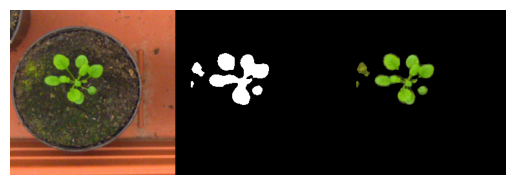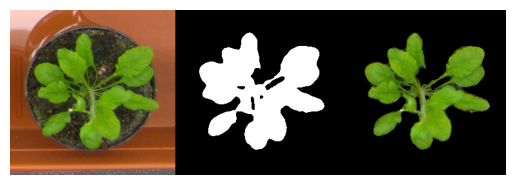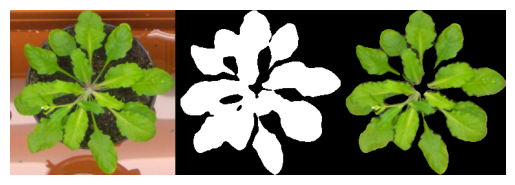

In [ ]:
# -*- coding: utf-8 -*-
"""leaf_Segmentation_save.ipynb




# Leaf Segmentation using UNet training and saving the weights
"""

from google.colab import drive
drive.mount('/content/gdrive',force_remount=True)

"""## Import packages"""

import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, Conv2DTranspose, Concatenate, BatchNormalization, UpSampling2D
from tensorflow.keras.layers import  Dropout, Activation
from tensorflow.keras.optimizers import Adam, SGD
from keras.layers import LeakyReLU
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras import backend as K
from tensorflow.keras.utils import plot_model
import tensorflow as tf
import glob
import random
import cv2
from random import shuffle

"""Note that we have two foulders. The first one is `images` which contains the raw images and annotation which contains the masks as a `binary` foulder image.

## Dataset Preparation
"""

def image_generator(files, batch_size =10 , sz = (256, 256)):

  while True:

    #extract a random batch
    batch = np.random.choice(files, size = batch_size)

    #variables for collecting batches of inputs and outputs
    batch_x = []
    batch_y = []


    for f in batch:

        #get the masks. Note that masks are png files
        mask = Image.open(f[-9::-1][::-1]+'_fg.png')
        mask = np.array(mask.resize(sz))


        #preprocess the mask
        mask[mask >= 2] = 0
        mask[mask != 0 ] = 1

        batch_y.append(mask)

        #preprocess the raw images
        raw = Image.open(f)
        raw = raw.resize(sz)
        raw = np.array(raw)

        #check the number of channels because some of the images are RGBA or GRAY
        if len(raw.shape) == 2:
          raw = np.stack((raw,)*3, axis=-1)

        else:
          raw = raw[:,:,0:3]

        batch_x.append(raw)

    #preprocess a batch of images and masks
    batch_x = np.array(batch_x)/255.
    batch_y = np.array(batch_y)
    batch_y = np.expand_dims(batch_y,3)

    yield (batch_x, batch_y)

all_files=[]
for i in os.listdir('/content/gdrive/My Drive/leaf1/images/A1'):
  if i[-5:]=='b.png':
    all_files.append('/content/gdrive/My Drive/leaf1/images/A1/'+i)



batch_size = 10
shuffle(all_files)
split = int(0.9 * len(all_files))
#split into training and testing
train_files = all_files[0:split]
test_files  = all_files[split:]

train_generator = image_generator(train_files, batch_size = batch_size)
test_generator  = image_generator(test_files, batch_size = batch_size)

x, y= next(train_generator)

"""# IoU metric

The intersection over union (IoU) metric is a simple metric used to evaluate the performance of a segmentation algorithm. Given two masks $x_{true}, x_{pred}$ we evaluate

$$IoU = \frac{y_{true} \cap y_{pred}}{y_{true} \cup y_{pred}}$$
"""

def mean_iou(y_true, y_pred):
    yt0 = y_true[:, :, :, 0]
    yp0 = K.cast(y_pred[:, :, :, 0] > 0.5, 'float32')
    yt0 = tf.cast(yt0, 'float32')  # Ensure consistent dtype
    inter = tf.math.count_nonzero(tf.logical_and(tf.equal(yt0, 1), tf.equal(yp0, 1)))
    union = tf.math.count_nonzero(tf.add(yt0, yp0))
    iou = tf.where(tf.equal(union, 0), 1., tf.cast(inter / union, 'float32'))
    return iou


"""# Model"""

def unet(sz = (256, 256, 3)):
  x = Input(sz)
  inputs = x

  #down sampling
  f = 8
  layers = []

  for i in range(0, 6):
    x = Conv2D(f, 3, activation='relu', padding='same') (x)
    x = Conv2D(f, 3, activation='relu', padding='same') (x)
    layers.append(x)
    x = MaxPooling2D() (x)
    f = f*2
  ff2 = 64

  #bottleneck
  j = len(layers) - 1
  x = Conv2D(f, 3, activation='tanh', padding='same') (x)
  x = Conv2D(f, 3, activation='tanh', padding='same') (x)
  x = Conv2DTranspose(ff2, 2, strides=(2, 2), padding='same') (x)
  x = Concatenate(axis=3)([x, layers[j]])
  j = j -1

  #upsampling
  for i in range(0, 5):
    ff2 = ff2//2
    f = f // 2
    x = Conv2D(f, 3, activation='tanh', padding='same') (x)
    x = Conv2D(f, 3, activation='tanh', padding='same') (x)
    x = Conv2DTranspose(ff2, 2, strides=(2, 2), padding='same') (x)
    x = Concatenate(axis=3)([x, layers[j]])
    j = j -1


  #classification
  x = Conv2D(f, 3, activation='tanh', padding='same') (x)
  x = Conv2D(f, 3, activation='tanh', padding='same') (x)
  outputs = Conv2D(1, 1, activation='sigmoid') (x)

  #model creation
  model = Model(inputs=[inputs], outputs=[outputs])
  model.compile(optimizer = 'rmsprop', loss = 'binary_crossentropy', metrics = [mean_iou])

  return model

model = unet()

model.summary()

"""# Training"""

train_steps = len(train_files) //batch_size
test_steps = len(test_files) //batch_size
model.fit(train_generator, epochs = 10, steps_per_epoch = train_steps,validation_data = test_generator, validation_steps = 10,verbose = 0)

model.save_weights('/content/gdrive/My Drive/project/weights_final.weights.h5')

Mounted at /content/gdrive


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_243 (Conv2D) │ (None, 256, 256,  │        224 │ input_layer_9[0]… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_244 (Conv2D) │ (None, 256, 256,  │        584 │ conv2d_243[0][0]  │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_54    │ (None, 128, 128,  │          0 │ conv2d_244[0][0]  │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_245 (Conv2D) │ (None, 128, 128,  │      1,168 │ max_pooling2d_54… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_246 (Conv2D) │ (None, 128, 128,  │      2,320 │ conv2d_245[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_55    │ (None, 64, 64,    │          0 │ conv2d_246[0][0]  │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_247 (Conv2D) │ (None, 64, 64,    │      4,640 │ max_pooling2d_55… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_248 (Conv2D) │ (None, 64, 64,    │      9,248 │ conv2d_247[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_56    │ (None, 32, 32,    │          0 │ conv2d_248[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_249 (Conv2D) │ (None, 32, 32,    │     18,496 │ max_pooling2d_56… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_250 (Conv2D) │ (None, 32, 32,    │     36,928 │ conv2d_249[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_57    │ (None, 16, 16,    │          0 │ conv2d_250[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_251 (Conv2D) │ (None, 16, 16,    │     73,856 │ max_pooling2d_57… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_252 (Conv2D) │ (None, 16, 16,    │    147,584 │ conv2d_251[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_58    │ (None, 8, 8, 128) │          0 │ conv2d_252[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_253 (Conv2D) │ (None, 8, 8, 256) │    295,168 │ max_pooling2d_58

 Total params: 6,667,639 (25.44 MB)

 Trainable params: 6,667,639 (25.44 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_414']
Received: inputs=Tensor(shape=(None, 256, 256, 3))
  warnings.warn(msg)


Mounted at /content/gdrive


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_828']
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step


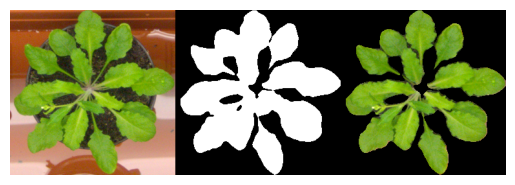

In [20]:
# -*- coding: utf-8 -*-
"""leaf_Segmentation_load.ipynb

Automatically generated by Colaboratory.

Original file is located at
    https://colab.research.google.com/drive/1H5JlOVxmqfAbP9FTqYLSVeWeMN4FIbal

# Leaf Segmentation using UNet loading part
"""

from google.colab import drive
drive.mount('/content/gdrive',force_remount=True)

"""## Import packages"""

import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, Conv2DTranspose, Concatenate, BatchNormalization, UpSampling2D
from tensorflow.keras.layers import  Dropout, Activation
from tensorflow.keras.optimizers import Adam, SGD
from keras.layers import LeakyReLU
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras import backend as K
from tensorflow.keras.utils import plot_model
import tensorflow as tf
import glob
import random
import cv2
from random import shuffle

"""# IoU metric

The intersection over union (IoU) metric is a simple metric used to evaluate the performance of a segmentation algorithm. Given two masks $x_{true}, x_{pred}$ we evaluate

$$IoU = \frac{y_{true} \cap y_{pred}}{y_{true} \cup y_{pred}}$$
"""

def mean_iou(y_true, y_pred):
    yt0 = y_true[:,:,:,0]
    yp0 = K.cast(y_pred[:,:,:,0] > 0.5, 'float32')
    inter = tf.count_nonzero(tf.logical_and(tf.equal(yt0, 1), tf.equal(yp0, 1)))
    union = tf.count_nonzero(tf.add(yt0, yp0))
    iou = tf.where(tf.equal(union, 0), 1., tf.cast(inter/union, 'float32'))
    return iou

"""# Model"""

def unet(sz = (256, 256, 3)):
  x = Input(sz)
  inputs = x

  #down sampling
  f = 8
  layers = []

  for i in range(0, 6):
    x = Conv2D(f, 3, activation='relu', padding='same') (x)
    x = Conv2D(f, 3, activation='relu', padding='same') (x)
    layers.append(x)
    x = MaxPooling2D() (x)
    f = f*2
  ff2 = 64

  #bottleneck
  j = len(layers) - 1
  x = Conv2D(f, 3, activation='tanh', padding='same') (x)
  x = Conv2D(f, 3, activation='tanh', padding='same') (x)
  x = Conv2DTranspose(ff2, 2, strides=(2, 2), padding='same') (x)
  x = Concatenate(axis=3)([x, layers[j]])
  j = j -1

  #upsampling
  for i in range(0, 5):
    ff2 = ff2//2
    f = f // 2
    x = Conv2D(f, 3, activation='tanh', padding='same') (x)
    x = Conv2D(f, 3, activation='tanh', padding='same') (x)
    x = Conv2DTranspose(ff2, 2, strides=(2, 2), padding='same') (x)
    x = Concatenate(axis=3)([x, layers[j]])
    j = j -1


  #classification
  x = Conv2D(f, 3, activation='tanh', padding='same') (x)
  x = Conv2D(f, 3, activation='tanh', padding='same') (x)
  outputs = Conv2D(1, 1, activation='sigmoid') (x)

  #model creation
  model = Model(inputs=[inputs], outputs=[outputs])
  model.compile(optimizer = 'rmsprop', loss = 'binary_crossentropy', metrics = [mean_iou])

  return model

model = unet()

model.load_weights('/content/gdrive/My Drive/project/weights_final.weights.h5')

"""## Prediction"""

raw = Image.open('/content/gdrive/My Drive/leaf1/images/A1/plant159_rgb.png')
raw = np.array(raw.resize((256, 256)))/255.
raw = raw[:,:,0:3]

#predict the mask
pred = model.predict(np.expand_dims(raw, 0))

#mask post-processing
msk  = pred.squeeze()
msk = np.stack((msk,)*3, axis=-1)
msk[msk >= 0.5] = 1
msk[msk < 0.5] = 0

#show the mask and the segmented image
combined = np.concatenate([raw, msk, raw* msk], axis = 1)
plt.axis('off')
plt.imshow(combined)
plt.show()

